In [1]:
import pandas as pd

df = pd.read_csv("phishing_url_dataset.csv")
print(df.shape)
df.head()

(2488, 14)


,url_length,valid_url,at_symbol,sensitive_words_count,path_length,isHttps,nb_dots,nb_hyphens,nb_and,nb_or,nb_www,nb_com,nb_underscore,target
0,42,0,0,0,20,0,2,0,0,0,1,1,0,0
1,73,0,0,0,52,0,5,0,0,0,0,1,0,0
2,73,0,0,0,52,0,5,0,0,0,0,1,0,0
3,73,0,0,0,52,0,5,1,0,1,0,1,0,0
4,73,0,0,0,52,0,5,0,0,0,0,1,0,0


In [2]:
import os
print("Current folder:", os.getcwd())
print("Files here:", os.listdir("."))

Current folder: C:\Users\user\phishing_project
Files here: ['.ipynb_checkpoints', '.venv', 'phishing_detection.ipynb', 'phishing_url_dataset.csv']


In [3]:
import pandas as pd
df = pd.read_csv("phishing_url_dataset.csv")
df.head()

,url_length,valid_url,at_symbol,sensitive_words_count,path_length,isHttps,nb_dots,nb_hyphens,nb_and,nb_or,nb_www,nb_com,nb_underscore,target
0,42,0,0,0,20,0,2,0,0,0,1,1,0,0
1,73,0,0,0,52,0,5,0,0,0,0,1,0,0
2,73,0,0,0,52,0,5,0,0,0,0,1,0,0
3,73,0,0,0,52,0,5,1,0,1,0,1,0,0
4,73,0,0,0,52,0,5,0,0,0,0,1,0,0


In [4]:
import pandas as pd

df = pd.read_csv("phishing_url_dataset.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(2488, 14)
['url_length', 'valid_url', 'at_symbol', 'sensitive_words_count', 'path_length', 'isHttps', 'nb_dots', 'nb_hyphens', 'nb_and', 'nb_or', 'nb_www', 'nb_com', 'nb_underscore', 'target']


,url_length,valid_url,at_symbol,sensitive_words_count,path_length,isHttps,nb_dots,nb_hyphens,nb_and,nb_or,nb_www,nb_com,nb_underscore,target
0,42,0,0,0,20,0,2,0,0,0,1,1,0,0
1,73,0,0,0,52,0,5,0,0,0,0,1,0,0
2,73,0,0,0,52,0,5,0,0,0,0,1,0,0
3,73,0,0,0,52,0,5,1,0,1,0,1,0,0
4,73,0,0,0,52,0,5,0,0,0,0,1,0,0


In [5]:
for c in df.columns:
    if df[c].nunique() <= 10:
        print("\n", c)
        print(df[c].value_counts())


 valid_url
valid_url
0    1791
1     697
Name: count, dtype: int64

 at_symbol
at_symbol
0    2482
1       4
8       1
9       1
Name: count, dtype: int64

 sensitive_words_count
sensitive_words_count
0    1934
1     532
2      20
3       2
Name: count, dtype: int64

 isHttps
isHttps
0    1424
1    1064
Name: count, dtype: int64

 nb_hyphens
nb_hyphens
0     1810
1      318
2      154
4       74
3       73
5       36
6       14
7        6
10       3
Name: count, dtype: int64

 nb_and
nb_and
0    2451
1      36
2       1
Name: count, dtype: int64

 nb_or
nb_or
0    2083
1     369
2      31
3       5
Name: count, dtype: int64

 nb_www
nb_www
0    1932
1     541
2      15
Name: count, dtype: int64

 nb_com
nb_com
1    1472
0     949
2      63
3       4
Name: count, dtype: int64

 nb_underscore
nb_underscore
0    2241
1     185
2      34
3      22
4       3
6       1
5       1
7       1
Name: count, dtype: int64

 target
target
0    1313
1    1175
Name: count, dtype: int64


In [6]:
target_col = "valid_url"

# 1 = phishing (positive class), 0 = legitimate
df["is_phishing"] = (df[target_col] == 0).astype(int)

df["is_phishing"].value_counts()

is_phishing
1    1791
0     697
Name: count, dtype: int64

In [7]:
import numpy as np

# clean any inf values if present
df = df.replace([np.inf, -np.inf], np.nan)

X = df.drop(columns=[target_col, "is_phishing"], errors="ignore")
y = df["is_phishing"]

# keep only numeric columns (safe if there is a url text column)
X = X.select_dtypes(include=["number"])

print(X.shape, y.shape)
X.head()

(2488, 13) (2488,)


,url_length,at_symbol,sensitive_words_count,path_length,isHttps,nb_dots,nb_hyphens,nb_and,nb_or,nb_www,nb_com,nb_underscore,target
0,42,0,0,20,0,2,0,0,0,1,1,0,0
1,73,0,0,52,0,5,0,0,0,0,1,0,0
2,73,0,0,52,0,5,0,0,0,0,1,0,0
3,73,0,0,52,0,5,1,0,1,0,1,0,0
4,73,0,0,52,0,5,0,0,0,0,1,0,0


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(is_phishing
 1    0.720101
 0    0.279899
 Name: proportion, dtype: float64,
 is_phishing
 1    0.718876
 0    0.281124
 Name: proportion, dtype: float64)

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

baseline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=500, class_weight="balanced"))
])

baseline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

In [10]:
from sklearn.metrics import (confusion_matrix, classification_report, 
                             roc_auc_score, average_precision_score)

pred = baseline.predict(X_test)
proba = baseline.predict_proba(X_test)[:, 1]

print("Confusion matrix:\n", confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC:", average_precision_score(y_test, proba))

Confusion matrix:
 [[123  17]
 [ 60 298]]
              precision    recall  f1-score   support

           0       0.67      0.88      0.76       140
           1       0.95      0.83      0.89       358

    accuracy                           0.85       498
   macro avg       0.81      0.86      0.82       498
weighted avg       0.87      0.85      0.85       498

ROC-AUC: 0.9333998403830807
PR-AUC: 0.9710189862716602


In [11]:
import lightgbm as lgb

imp = SimpleImputer(strategy="median")
X_train_i = imp.fit_transform(X_train)
X_test_i  = imp.transform(X_test)

lgbm = lgb.LGBMClassifier(
    n_estimators=800,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    class_weight="balanced",
    random_state=42
)

lgbm.fit(X_train_i, y_train)

proba_lgb = lgbm.predict_proba(X_test_i)[:, 1]
pred_lgb = (proba_lgb >= 0.5).astype(int)

print("Confusion matrix:\n", confusion_matrix(y_test, pred_lgb))
print(classification_report(y_test, pred_lgb))
print("ROC-AUC:", roc_auc_score(y_test, proba_lgb))
print("PR-AUC:", average_precision_score(y_test, proba_lgb))

[LightGBM] [Info] Number of positive: 1433, number of negative: 557
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005895 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 165
[LightGBM] [Info] Number of data points in the train set: 1990, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

C:\Users\user\phishing_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [12]:
import pandas as pd
from sklearn.impute import SimpleImputer
import lightgbm as lgb

imp = SimpleImputer(strategy="median")

X_train_i = pd.DataFrame(
    imp.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_i = pd.DataFrame(
    imp.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

lgbm = lgb.LGBMClassifier(
    n_estimators=800,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    class_weight="balanced",
    random_state=42
)

lgbm.fit(X_train_i, y_train)

proba_lgb = lgbm.predict_proba(X_test_i)[:, 1]

[LightGBM] [Info] Number of positive: 1433, number of negative: 557
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001947 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 165
[LightGBM] [Info] Number of data points in the train set: 1990, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

In [13]:
import numpy as np
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report, average_precision_score

prec, rec, thr = precision_recall_curve(y_test, proba_lgb)
f1 = 2*(prec*rec)/(prec+rec+1e-9)

best_idx = np.argmax(f1)
best_thr = thr[best_idx]
best_thr

np.float64(0.33997688500658646)

In [14]:
pred_thr = (proba_lgb >= best_thr).astype(int)

print("PR-AUC:", average_precision_score(y_test, proba_lgb))
print("Threshold:", best_thr)
print(confusion_matrix(y_test, pred_thr))
print(classification_report(y_test, pred_thr))

PR-AUC: 0.9877211844875851
Threshold: 0.33997688500658646
[[128  12]
 [  9 349]]
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       140
           1       0.97      0.97      0.97       358

    accuracy                           0.96       498
   macro avg       0.95      0.94      0.95       498
weighted avg       0.96      0.96      0.96       498



C:\Users\user\phishing_project\.venv\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


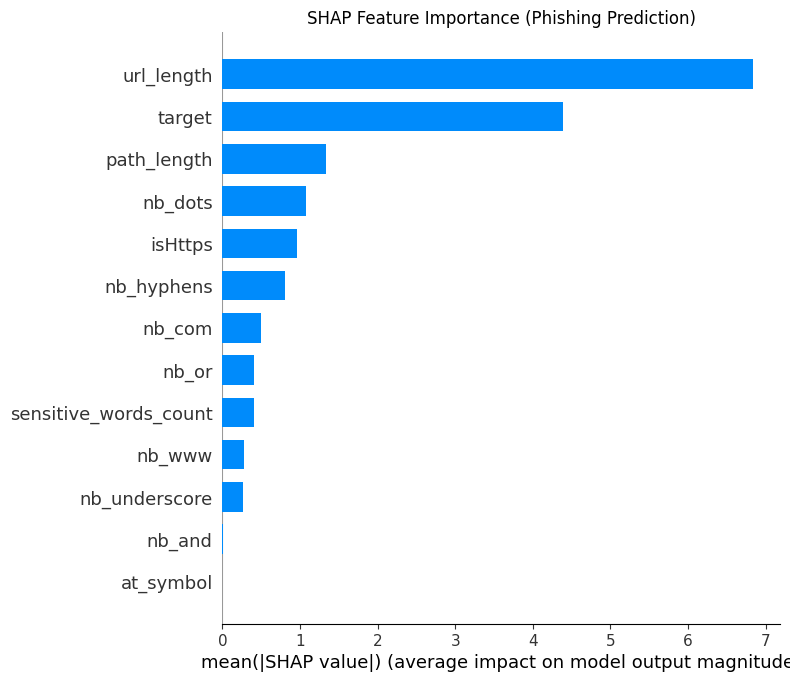

In [17]:
import shap
import matplotlib.pyplot as plt

# X_test_i should be a DataFrame with columns (recommended).
# If your X_test_i is numpy array, create DataFrame first:
# X_test_i = pd.DataFrame(X_test_i, columns=X_test.columns, index=X_test.index)

explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test_i)

shap.summary_plot(shap_values, X_test_i, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Phishing Prediction)")
plt.show()

In [16]:
!pip install -U ipywidgets jupyterlab_widgets

In [18]:
import pandas as pd

pred_thr = (proba_lgb >= best_thr).astype(int)

results = X_test.copy()
results["y_true"] = y_test.values
results["score"] = proba_lgb
results["y_pred"] = pred_thr

fp = results[(results.y_true==0) & (results.y_pred==1)]  # legit predicted phishing
fn = results[(results.y_true==1) & (results.y_pred==0)]  # phishing predicted legit

print("False Positives:", len(fp))
print("False Negatives:", len(fn))

fp.head(), fn.head()

False Positives: 12
False Negatives: 9


(      url_length  at_symbol  sensitive_words_count  path_length  isHttps  \
 1465          17          0                      0            0        1   
 2137          69          0                      1            0        0   
 1328          24          0                      0            1        0   
 1334          49          0                      0            3        0   
 1921          36          0                      0            4        0   
 
       nb_dots  nb_hyphens  nb_and  nb_or  nb_www  nb_com  nb_underscore  \
 1465        0           0       0      0       0       0              1   
 2137        8           0       0      0       0       0              0   
 1328        1           0       0      1       0       1              0   
 1334        7           1       0      0       0       1              0   
 1921        1           0       0      1       0       1              0   
 
       target  y_true     score  y_pred  
 1465       1       0  0.999958     

In [19]:
import joblib

joblib.dump(
    {
        "model": lgbm,
        "imputer": imp,
        "threshold": float(best_thr),
        "feature_names": list(X.columns)
    },
    "phishing_model_bundle.joblib"
)

print("Saved: phishing_model_bundle.joblib")

Saved: phishing_model_bundle.joblib


In [20]:
import numpy as np
import pandas as pd

bundle = joblib.load("phishing_model_bundle.joblib")
model = bundle["model"]
imputer = bundle["imputer"]
thr = bundle["threshold"]
feat = bundle["feature_names"]

def predict_from_features(feature_dict):
    x = pd.DataFrame([feature_dict])[feat]
    x_i = pd.DataFrame(imputer.transform(x), columns=feat)
    score = model.predict_proba(x_i)[:, 1][0]
    pred = int(score >= thr)
    return {"score": float(score), "prediction": pred}  # 1=phishing (if that is your setup)

In [21]:
# Take one sample from your test set
sample = X_test.iloc[0].to_dict()

out = predict_from_features(sample)
out

{'score': 0.9969901295708007, 'prediction': 1}

In [22]:
for i in range(5):
    out = predict_from_features(X_test.iloc[i].to_dict())
    print(i, out)

0 {'score': 0.9969901295708007, 'prediction': 1}
1 {'score': 0.9999999664536476, 'prediction': 1}
2 {'score': 0.9998004515321444, 'prediction': 1}
3 {'score': 0.9999999996524043, 'prediction': 1}
4 {'score': 4.004544153977602e-08, 'prediction': 0}


In [23]:
i = 0
print("True:", int(y_test.iloc[i]))
print("Pred:", predict_from_features(X_test.iloc[i].to_dict()))

True: 1
Pred: {'score': 0.9969901295708007, 'prediction': 1}


In [24]:
def policy(score, block=0.80, warn=0.50):
    if score >= block:
        return "BLOCK"
    elif score >= warn:
        return "WARN"
    else:
        return "ALLOW"

# Example on some test predictions
scores = model.predict_proba(pd.DataFrame(imputer.transform(X_test[feat]), columns=feat))[:, 1]
pd.Series([policy(s) for s in scores]).value_counts()

BLOCK    360
ALLOW    138
Name: count, dtype: int64

In [25]:
scores = model.predict_proba(pd.DataFrame(imputer.transform(X_test[feat]), columns=feat))[:, 1]
preds = (scores >= thr).astype(int)

export_df = X_test.copy()
export_df["y_true"] = y_test.values
export_df["score"] = scores
export_df["y_pred"] = preds
export_df["action"] = [policy(s) for s in scores]

export_df.to_csv("outputs_test_predictions.csv", index=False)
"Saved outputs_test_predictions.csv"

'Saved outputs_test_predictions.csv'

In [26]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
print("RANDOM_STATE:", RANDOM_STATE, "TEST_SIZE:", TEST_SIZE)

RANDOM_STATE: 42 TEST_SIZE: 0.2
